In [1]:
import torch
import random
import json

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from PIL import Image
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split


In [2]:
BASE_DIR = Path().resolve()
DATASET_DIR = BASE_DIR / "dataset" / "Lung X-Ray Image" / "Lung X-Ray Image"

MODELS_DIR = BASE_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODELS_DIR / "lung_model.pt"
LABELS_PATH = MODELS_DIR / "lung_labels.json"

IMAGE_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 5
LEARNING_RATE = 1e-3
SEED = 42

In [3]:
def set_seed(seed):
    random.seed(seed)
    torch.manual_seed(seed)

set_seed(SEED)

In [4]:
class LungXRayDataset(Dataset):
    def __init__(self, root_dir, image_size=128):
        self.root_dir = root_dir
        self.image_size = image_size

        self.class_names = sorted([f.name for f in root_dir.iterdir() if f.is_dir()])
        self.class_to_idx = {name: idx for idx, name in enumerate(self.class_names)}

        self.samples = []
        for class_name in self.class_names:
            class_dir = root_dir / class_name
            for img_path in class_dir.rglob("*"):
                if img_path.suffix.lower() in [".png", ".jpg", ".jpeg"]:
                    self.samples.append((img_path, self.class_to_idx[class_name]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        img_path, label = self.samples[index]

        image = Image.open(img_path).convert("RGB").resize((self.image_size, self.image_size))

        tensor = torch.tensor(list(image.getdata()), dtype=torch.float32)
        tensor = tensor.view(self.image_size, self.image_size, 3)
        tensor = tensor.permute(2, 0, 1) / 255.0

        return tensor, label

In [5]:
dataset = LungXRayDataset(DATASET_DIR, IMAGE_SIZE)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

print("Classes:", dataset.class_names)
print("Total samples:", len(dataset))

Classes: ['Lung_Opacity', 'Normal', 'Viral Pneumonia']
Total samples: 3475


In [6]:
class SimpleLungCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleLungCNN(len(dataset.class_names)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [8]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

def evaluate(model, loader):
    model.eval()
    total_loss, total_correct, total = 0, 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item() * y.size(0)
            total_correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

    return total_loss/total, total_correct/total

In [9]:
for epoch in range(EPOCHS):
    model.train()
    running_loss, running_correct, total = 0, 0, 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * y.size(0)
        running_correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)

    train_loss = running_loss / total
    train_acc = running_correct / total

    val_loss, val_acc = evaluate(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

Epoch 1: Train Acc=0.3576, Val Acc=0.3698
Epoch 2: Train Acc=0.4975, Val Acc=0.6863
Epoch 3: Train Acc=0.6532, Val Acc=0.6633
Epoch 4: Train Acc=0.6971, Val Acc=0.7525
Epoch 5: Train Acc=0.7241, Val Acc=0.7540


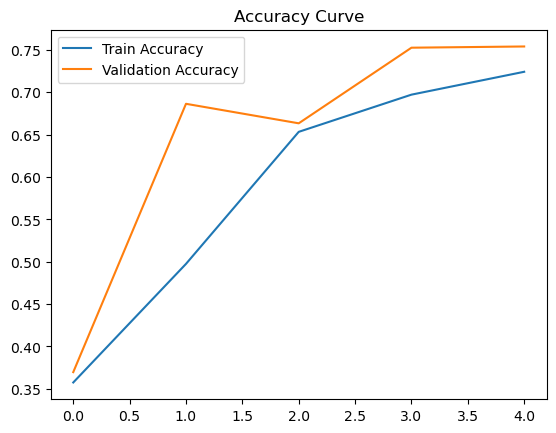

In [10]:
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [11]:
torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": dataset.class_names,
    "image_size": IMAGE_SIZE
}, MODEL_PATH)

LABELS_PATH.write_text(json.dumps(dataset.class_names, indent=2))

print("Model saved successfully!")

Model saved successfully!
